In [5]:
# Cell 1 — imports & config
import os
import math
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

DATA_PATH = Path("../data/index/index.parquet")  # здесь лежит твой parquet в этой среде


In [6]:
# Cell 2 — load parquet
df = pd.read_parquet(DATA_PATH)
print("shape:", df.shape)
df.head(3)


shape: (1885, 13)


,ad_id,url,price,area,price_per_m2,log_price_per_m2,rooms,district,building_type,year_built,floor,floors_total,image_paths
0,1002526087,https://krisha.kz/a/show/1002526087,56500000,75.1,7.523302e+05,13.530931,3,Алмалинский р-н,монолитный,2023,14,15,"[data/images/1002526087/01.jpg, data/images/10..."
1,1005774259,https://krisha.kz/a/show/1005774259,130000000,95.0,1.368421e+06,14.129168,3,Алмалинский р-н,монолитный,2024,17,17,"[data/images/1005774259/01.jpg, data/images/10..."
2,1000941933,https://krisha.kz/a/show/1000941933,50000000,56.5,8.849558e+05,13.693293,2,Наурызбайский р-н,монолитный,2024,3,4,"[data/images/1000941933/01.jpg, data/images/10..."


In [7]:
# Cell 3 — schema & quick stats
display(df.dtypes)
display(df.describe(include="all").T)


ad_id                object
url                  object
price                 int64
area                float64
price_per_m2        float64
log_price_per_m2    float64
rooms                 int64
district             object
building_type        object
year_built            int64
floor                 int64
floors_total          int64
image_paths          object
dtype: object

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
ad_id,1885,1885,1002526087,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
url,1885,1885,https://krisha.kz/a/show/1002526087,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
price,1885.0,NaN,NaN,NaN,58865767.709284,53797211.54353,1000000.0,32670000.0,45000000.0,65600000.0,750000000.0
area,1885.0,NaN,NaN,NaN,71.025714,40.733276,8.2,47.0,62.3,81.0,480.0
price_per_m2,1885.0,NaN,NaN,NaN,788159.430735,250035.664482,41666.666667,609939.759036,739583.333333,909090.909091,2600000.0
log_price_per_m2,1885.0,NaN,NaN,NaN,13.532506,0.298021,10.637457,13.321115,13.513842,13.7202,14.771022
rooms,1885.0,NaN,NaN,NaN,2.314589,0.964456,1.0,2.0,2.0,3.0,8.0
district,1885,8,Бостандыкский р-н,409,NaN,NaN,NaN,NaN,NaN,NaN,NaN
building_type,1885,4,монолитный,1379,NaN,NaN,NaN,NaN,NaN,NaN,NaN
year_built,1885.0,NaN,NaN,NaN,2008.881698,19.148384,1950.0,1997.0,2018.0,2023.0,2026.0


In [10]:
# Cell 4 — required columns check
required = [
    "ad_id","url","price","area","price_per_m2","log_price_per_m2",
    "rooms","district","building_type","year_built",
    "floor","floors_total","image_paths"
]
missing = [c for c in required if c not in df.columns]
print("Missing columns:", missing)


Missing columns: []


In [11]:
# Cell 5 — nulls / empties
nulls = df.isna().mean().sort_values(ascending=False)
display((nulls * 100).round(2).to_frame("% null"))

# empty strings for some categorical columns (if any)
for c in ["city","district","building_type","url"]:
    if c in df.columns:
        empty_rate = (df[c].astype(str).str.strip() == "").mean()
        print(f"{c}: empty string rate = {empty_rate:.3%}")


,% null
ad_id,0.0
url,0.0
price,0.0
area,0.0
price_per_m2,0.0
log_price_per_m2,0.0
rooms,0.0
district,0.0
building_type,0.0
year_built,0.0


district: empty string rate = 0.000%
building_type: empty string rate = 0.000%
url: empty string rate = 0.000%


In [12]:
# Cell 6 — duplicates
print("Duplicate ad_id:", df["ad_id"].duplicated().sum())
print("Duplicate url:", df["url"].duplicated().sum())


Duplicate ad_id: 0
Duplicate url: 0


In [13]:
# Cell 7 — numeric sanity checks
def count_bad(series, name):
    s = pd.to_numeric(series, errors="coerce")
    bad = (~np.isfinite(s)).sum()
    print(f"{name}: non-finite count = {bad}")

count_bad(df["price"], "price")
count_bad(df["area"], "area")
count_bad(df["price_per_m2"], "price_per_m2")
count_bad(df["log_price_per_m2"], "log_price_per_m2")

# obvious invalids
invalid = {
    "price<=0": int((df["price"] <= 0).sum()),
    "area<=0": int((df["area"] <= 0).sum()),
    "ppm2<=0": int((df["price_per_m2"] <= 0).sum()),
    "rooms<=0": int((df["rooms"] <= 0).sum()),
    "floor<=0": int((df["floor"] <= 0).sum()),
    "floors_total<=0": int((df["floors_total"] <= 0).sum()),
    "floor>floors_total": int((df["floor"] > df["floors_total"]).sum()),
}
invalid


price: non-finite count = 0
area: non-finite count = 0
price_per_m2: non-finite count = 0
log_price_per_m2: non-finite count = 0


{'price<=0': 0,
 'area<=0': 0,
 'ppm2<=0': 0,
 'rooms<=0': 0,
 'floor<=0': 0,
 'floors_total<=0': 0,
 'floor>floors_total': 0}

max abs diff: 0.0
mean abs diff: 0.0


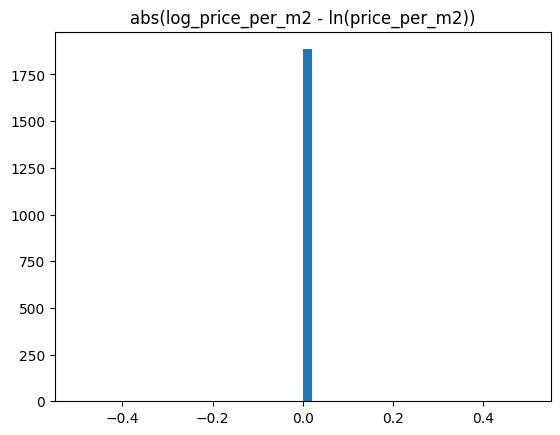

In [14]:
# Cell 8 — check log correctness: log_price_per_m2 ≈ ln(price_per_m2)
ppm2 = df["price_per_m2"].astype(float).values
logp = df["log_price_per_m2"].astype(float).values

diff = np.abs(logp - np.log(ppm2))
print("max abs diff:", np.nanmax(diff))
print("mean abs diff:", np.nanmean(diff))

plt.figure()
plt.hist(diff[~np.isnan(diff)], bins=50)
plt.title("abs(log_price_per_m2 - ln(price_per_m2))")
plt.show()


image count stats:


count    1885.000000
mean        6.806366
std         0.710971
min         3.000000
25%         7.000000
50%         7.000000
75%         7.000000
max         7.000000
Name: image_paths_list, dtype: float64

np.int64(3)

np.int64(7)

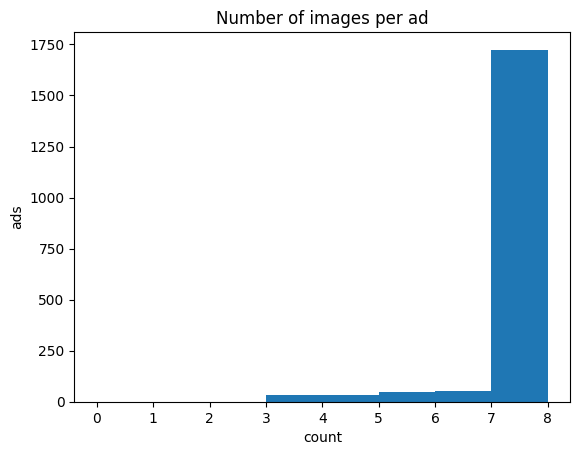

,ad_id,image_paths
0,1002526087,"[data/images/1002526087/01.jpg, data/images/10..."
1,1005774259,"[data/images/1005774259/01.jpg, data/images/10..."
2,1000941933,"[data/images/1000941933/01.jpg, data/images/10..."


In [17]:
# Cell 9 — image_paths: type, count distribution, sample
# image_paths should be list-like; if it's stringified JSON, we can parse safely

def ensure_list(x):
    # already list-like
    if isinstance(x, (list, tuple)):
        return list(x)

    if isinstance(x, np.ndarray):
        return x.tolist()

    # missing
    if x is None:
        return []

    # string (json or comma-separated)
    if isinstance(x, str):
        s = x.strip()
        if not s:
            return []
        if s.startswith("[") and s.endswith("]"):
            try:
                return json.loads(s)
            except Exception:
                pass
        return [p.strip().strip('"').strip("'") for p in s.split(",") if p.strip()]

    return []


df["image_paths_list"] = df["image_paths"].apply(ensure_list)
img_counts = df["image_paths_list"].apply(len)

print("image count stats:")
display(img_counts.describe())
display(img_counts.min())
display(img_counts.max())

plt.figure()
plt.hist(img_counts, bins=range(0, int(img_counts.max()) + 2))
plt.title("Number of images per ad")
plt.xlabel("count")
plt.ylabel("ads")
plt.show()

df[["ad_id","image_paths"]].head(3)


In [19]:
# Cell 10 — verify image files exist (fast check)
# Adjust ROOT if needed. Here we try:
# 1) as-is paths (relative to current working dir)
# 2) relative to /mnt/data

PROJECT_ROOT = Path("/Users/zhasik/Desktop/krisha")   # <-- твой проект
ROOTS = [PROJECT_ROOT, PROJECT_ROOT / "data", Path(".")]

def resolve_existing(p: str):
    p = str(p)
    # если путь абсолютный
    ap = Path(p)
    if ap.is_absolute() and ap.exists():
        return ap

    # пробуем как относительный к разным корням
    for r in ROOTS:
        cand = (r / p).resolve()
        if cand.exists():
            return cand
    return None

exist_rates = []
missing_examples = []

for _, row in df[["ad_id","image_paths_list"]].iterrows():
    paths = row["image_paths_list"]
    if not paths:
        exist_rates.append((row["ad_id"], 0, 0))
        continue
    ok = sum(resolve_existing(p) is not None for p in paths)
    exist_rates.append((row["ad_id"], ok, len(paths)))
    if ok < len(paths) and len(missing_examples) < 10:
        missing_examples.append((row["ad_id"], [p for p in paths if resolve_existing(p) is None][:5]))

exist_df = pd.DataFrame(exist_rates, columns=["ad_id","n_exist","n_total"])
exist_df["exist_ratio"] = exist_df["n_exist"] / exist_df["n_total"].replace(0, np.nan)

print("Ads with 0 images:", int((exist_df["n_total"]==0).sum()))
print("Avg exist ratio (excluding 0 total):", float(exist_df["exist_ratio"].mean()))
print("Ads with missing images:", int((exist_df["n_exist"] < exist_df["n_total"]).sum()))
print("\nMissing examples (up to 10):")
missing_examples


Ads with 0 images: 0
Avg exist ratio (excluding 0 total): 1.0
Ads with missing images: 0

Missing examples (up to 10):


[]

ad_id                                     1007714568
url              https://krisha.kz/a/show/1007714568
price                                       32000000
area                                            38.4
rooms                                              1
district                           Наурызбайский р-н
building_type                             монолитный
year_built                                      2023
floor                                             10
floors_total                                      12
price_per_m2                           833333.333333


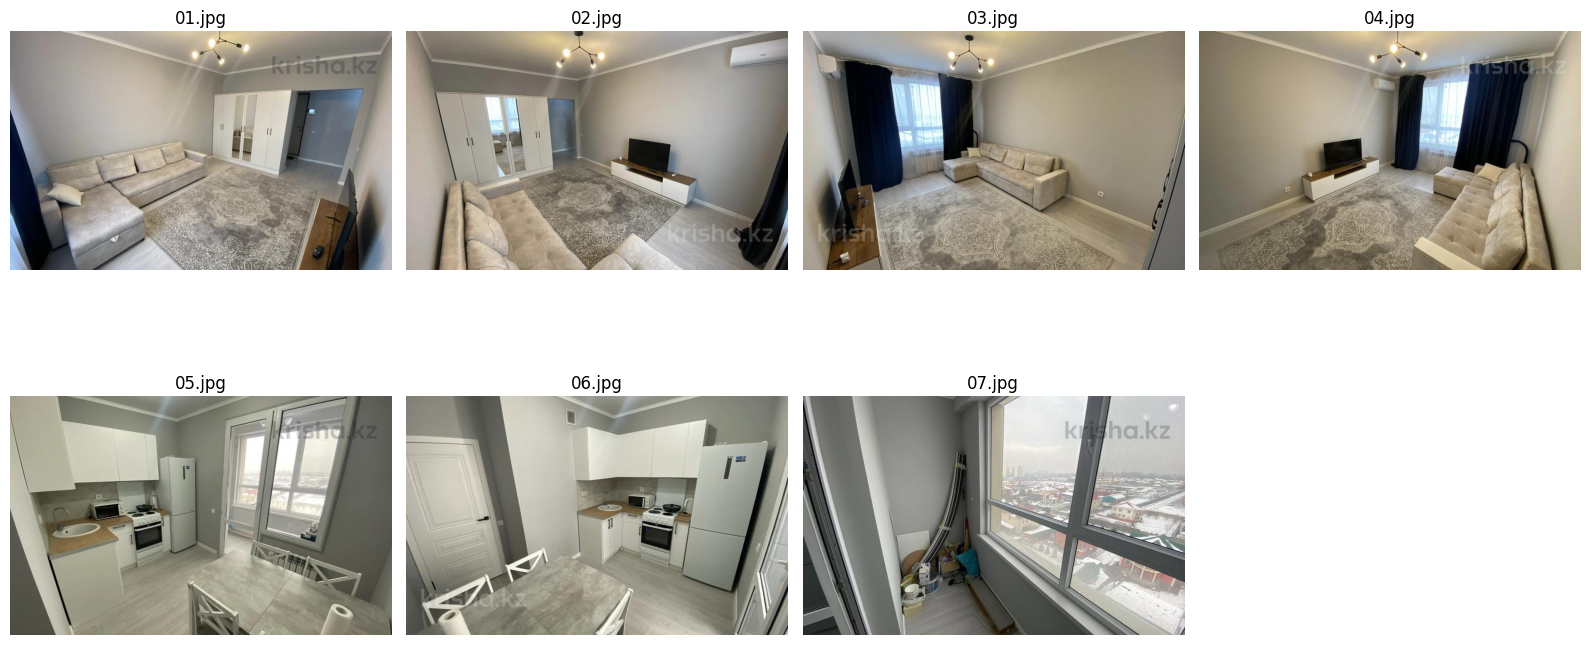

In [20]:
from PIL import Image
import matplotlib.pyplot as plt
from pathlib import Path

PROJECT_ROOT = Path("/Users/zhasik/Desktop/krisha")  # твой корень

def resolve_path(p: str) -> Path:
    ap = Path(p)
    if ap.is_absolute():
        return ap
    return (PROJECT_ROOT / p).resolve()

def show_ad(ad_id: str, max_imgs: int = 7):
    row = df.loc[df["ad_id"].astype(str) == str(ad_id)].iloc[0]
    paths = row["image_paths_list"][:max_imgs]

    # печать инфы
    cols = ["ad_id","url","price","area","rooms","district","building_type","year_built","floor","floors_total","price_per_m2"]
    print(row[cols].to_string())

    # grid
    n = len(paths)
    if n == 0:
        print("No images")
        return

    cols_grid = 4
    rows_grid = (n + cols_grid - 1) // cols_grid
    plt.figure(figsize=(4 * cols_grid, 4 * rows_grid))

    for i, p in enumerate(paths, 1):
        fp = resolve_path(p)
        img = Image.open(fp).convert("RGB")
        ax = plt.subplot(rows_grid, cols_grid, i)
        ax.imshow(img)
        ax.set_title(fp.name)
        ax.axis("off")

    plt.tight_layout()
    plt.show()

# пример: покажем случайный ad
random_ad = df["ad_id"].astype(str).sample(1).iloc[0]
show_ad(random_ad)


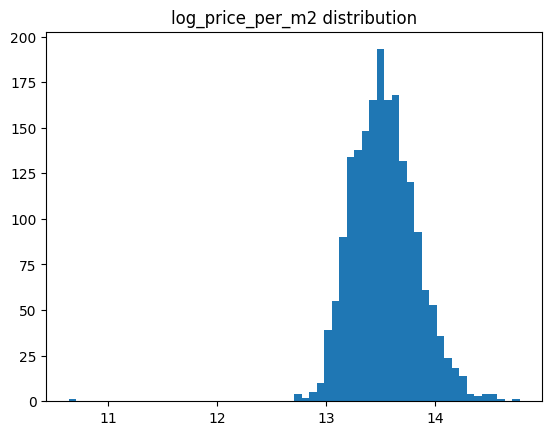

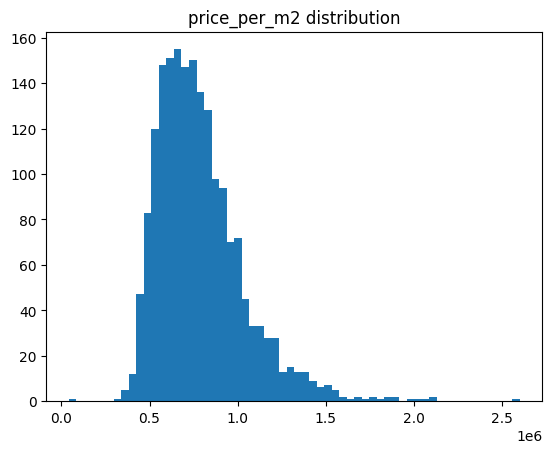

,ad_id,district,building_type,year_built,area,rooms,price,price_per_m2
308,1007539539,Жетысуский р-н,панельный,2016,24.0,1,1000000,41666.666667
72,1002200130,Алатауский р-н,монолитный,2025,49.0,3,16500000,336734.693878
1803,1007772717,Турксибский р-н,кирпичный,1982,42.0,1,14500000,345238.095238
1373,1007169062,Алатауский р-н,монолитный,2019,86.4,3,30000000,347222.222222
1706,1005601537,Алатауский р-н,монолитный,2025,44.0,2,15500000,352272.727273
576,1002311701,Турксибский р-н,кирпичный,1978,52.7,2,19600000,371916.508539
1681,1002736192,Наурызбайский р-н,монолитный,2025,73.5,3,27700000,376870.748299
913,1001131387,Наурызбайский р-н,монолитный,2012,92.3,2,35400000,383531.960997
925,1001359852,Наурызбайский р-н,монолитный,2019,78.0,3,29999999,384615.371795
668,1007618241,Алатауский р-н,монолитный,2025,34.0,2,13500000,397058.823529


,ad_id,district,building_type,year_built,area,rooms,price,price_per_m2
685,1007528876,Бостандыкский р-н,монолитный,2022,125.0,3,325000000,2.600000e+06
1203,1008072803,Медеуский р-н,монолитный,2022,235.0,4,500000000,2.127660e+06
677,1007877646,Медеуский р-н,монолитный,2022,206.6,5,435000000,2.105518e+06
712,1007019775,Медеуский р-н,монолитный,2017,290.0,7,600000000,2.068966e+06
696,1007443021,Медеуский р-н,монолитный,2024,207.0,4,420000000,2.028986e+06
1694,1007880560,Бостандыкский р-н,монолитный,2017,300.0,5,600000000,2.000000e+06
1355,1007933049,Медеуский р-н,монолитный,2017,250.0,5,479000000,1.916000e+06
1439,1005850645,Бостандыкский р-н,кирпичный,2023,184.0,3,350000000,1.902174e+06
750,1007019364,Бостандыкский р-н,монолитный,2023,150.0,4,280000000,1.866667e+06
679,1006039502,Бостандыкский р-н,монолитный,2024,92.6,4,172000000,1.857451e+06


In [21]:
# Cell 11 — target distribution & outliers
plt.figure()
plt.hist(df["log_price_per_m2"].astype(float), bins=60)
plt.title("log_price_per_m2 distribution")
plt.show()

plt.figure()
plt.hist(df["price_per_m2"].astype(float), bins=60)
plt.title("price_per_m2 distribution")
plt.show()

# show top/bottom ppm2
display(df.sort_values("price_per_m2")[["ad_id","district","building_type","year_built","area","rooms","price","price_per_m2"]].head(10))
display(df.sort_values("price_per_m2", ascending=False)[["ad_id","district","building_type","year_built","area","rooms","price","price_per_m2"]].head(10))


In [22]:
# Cell 12 — category balance (районы / типы домов / комнаты)
for c in ["district","building_type","rooms"]:
    vc = df[c].value_counts(dropna=False).head(30)
    print("\n", c)
    display(vc.to_frame("count"))



 district


,count
district,
Бостандыкский р-н,409
Алатауский р-н,280
Ауэзовский р-н,271
Алмалинский р-н,263
Наурызбайский р-н,242
Медеуский р-н,200
Турксибский р-н,132
Жетысуский р-н,88



 building_type


,count
building_type,
монолитный,1379
панельный,246
кирпичный,240
иной,20



 rooms


,count
rooms,
2,734
3,623
1,381
4,111
5,23
6,7
7,4
8,2


,price,area,price_per_m2,log_price_per_m2,rooms,year_built,floor,floors_total
price,1.000000,0.862281,0.636227,0.557906,0.635318,0.101577,0.130572,0.137425
area,0.862281,1.000000,0.283532,0.241013,0.793198,0.115098,0.179768,0.176936
price_per_m2,0.636227,0.283532,1.000000,0.964009,0.209163,0.028002,0.117593,0.174952
log_price_per_m2,0.557906,0.241013,0.964009,1.000000,0.190106,-0.007094,0.113631,0.182659
rooms,0.635318,0.793198,0.209163,0.190106,1.000000,-0.085357,0.093169,0.074694
year_built,0.101577,0.115098,0.028002,-0.007094,-0.085357,1.000000,0.283317,0.446642
floor,0.130572,0.179768,0.117593,0.113631,0.093169,0.283317,1.000000,0.672453
floors_total,0.137425,0.176936,0.174952,0.182659,0.074694,0.446642,0.672453,1.000000


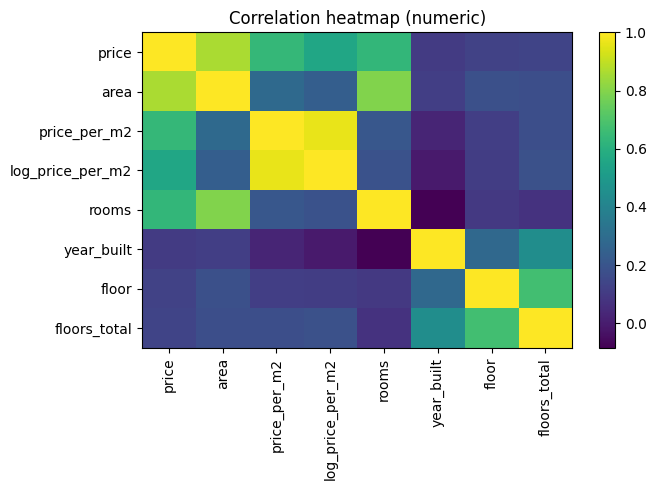

In [23]:
# Cell 13 — quick correlations (numeric only)
num_cols = ["price","area","price_per_m2","log_price_per_m2","rooms","year_built","floor","floors_total"]
corr = df[num_cols].astype(float).corr()
display(corr)

plt.figure(figsize=(7,5))
plt.imshow(corr, aspect="auto")
plt.xticks(range(len(num_cols)), num_cols, rotation=90)
plt.yticks(range(len(num_cols)), num_cols)
plt.title("Correlation heatmap (numeric)")
plt.colorbar()
plt.tight_layout()
plt.show()
